<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2d6a9f 100%); padding: 40px 32px 32px 32px; border-radius: 12px; margin-bottom: 8px;">
  <h1 style="color: #ffffff; font-size: 2.0em; margin: 0 0 6px 0; font-family: 'Segoe UI', sans-serif; font-weight: 700;">
    🪨 Week 5, Lesson 9 -- Classification Models
  </h1>
  <h2 style="color: #a8d4f5; font-size: 1.2em; margin: 0 0 18px 0; font-family: 'Segoe UI', sans-serif; font-weight: 400;">
    Predicting Formation Type from Well Logs using Decision Trees
  </h2>
  <hr style="border: 1px solid rgba(255,255,255,0.25); margin: 16px 0;">
  <table style="color: #cce4ff; font-family: 'Segoe UI', sans-serif; font-size: 0.95em;">
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>📅 Week:</strong></td><td>5 (Lesson 9) -- Classification</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>⏱️ Duration:</strong></td><td>40 Minutes</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>🎯 Track:</strong></td><td>Petroleum Engineers &amp; Geoscientists</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>👤 Audience:</strong></td><td>Engineers · Geoscientists</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>🧑‍🏫 Instructor:</strong></td><td>Dr. Daniel Wamriew</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>✉️ Contact:</strong></td><td>wamriewdan@gmail.com</td>
    </tr>
  </table>
</div>

<div style="background: #e8f5e9; border-left: 5px solid #2ca87f; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### 💡 How to Use This Notebook

Work through this notebook **from top to bottom**, pressing **Shift + Enter** on each cell to run it.

- **Code cells** contain Python -- run them and read the output carefully.
- **Markdown cells** (white background) contain explanations -- read before running the next cell.
- **Student Activity** cells are marked with 🎯 -- complete these before moving on.
- **Homework** cells are marked with 📝 -- complete after the session.
- You need **`well_log_data.csv`** in the same folder as this notebook.

</div>

---
## 📋 Table of Contents

1. [Why Classification?](#1-why-classification)
2. [Regression vs Classification](#2-regression-vs-classification)
3. [What is a Decision Tree?](#3-what-is-a-decision-tree)
4. [Prepare the Data](#4-prepare-the-data)
5. [Build and Train the Model](#5-build-and-train-the-model)
6. [Evaluate the Model](#6-evaluate-the-model)
7. [Feature Importance](#7-feature-importance)
8. [Student Activity](#8-student-activity)
9. [Recap & Homework](#9-recap-homework)

---
## 1. Why Classification?

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

In Lesson 8 you predicted a **continuous number** (porosity) -- that is **regression**.

Many real problems require predicting a **category** instead:

| Question | Output type | ML task |
|----------|-------------|----------|
| What will NPHI be at 2050 m? | A number | Regression |
| Is this interval Sand, Shaly Sand, or Shale? | A label | Classification |
| Will this well be a producer or a dry hole? | A label | Classification |
| Which of 5 formations does this log signature belong to? | A label | Classification |

In this lesson the model will look at GR, RHOB, NPHI, RT, and SW measurements
and predict **which formation** each depth interval belongs to -- something a petrophysicist
does manually every day using crossplots and pattern recognition.

</div>

---
## 2. Regression vs Classification

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

| | Regression | Classification |
|-|------------|----------------|
| **Predicts** | A number | A category / label |
| **Example output** | NPHI = 0.243 | Formation = "Reservoir_1" |
| **Loss function** | Mean Squared Error | Cross-entropy / Gini impurity |
| **Evaluation metric** | R², RMSE | Accuracy, Precision, Recall, F1 |
| **scikit-learn** | `LinearRegression()` | `DecisionTreeClassifier()` |

The 5-step ML workflow is **identical** -- only the model class and evaluation metrics change.

</div>

---
## 3. What is a Decision Tree?

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

A Decision Tree splits data step by step using **if/else questions** on the feature values.
At each split it chooses the question that best separates the classes.

**Example for lithology:**
```
Is GR_API < 55?
    YES --> Is RHOB_gcc < 2.25?
                YES --> Reservoir_1 (clean sand, porous)
                NO  --> Reservoir_2
    NO  --> Is GR_API < 90?
                YES --> Transition or Shaly_Sand
                NO  --> Shale_Cap or Basement
```

**Why Decision Trees are great for geology:**
- The learned rules are human-readable -- you can inspect exactly what the model is doing
- They handle multiple classes naturally (no modification needed for 5 formations)
- Feature importance tells you which logs are most diagnostic

</div>

---
## 4. Prepare the Data

We use `well_log_data.csv`. The **features** are the 5 log measurements; the **target** is the Formation label.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)

print("Libraries loaded.")

Libraries loaded.


In [5]:
# Load and clean (same as previous lessons)
df = pd.read_csv("well_log_data.csv")
log_cols = ["GR_API", "NPHI_frac", "RHOB_gcc", "RT_ohmm", "SW_frac"]
df[log_cols] = df.groupby("Well_ID")[log_cols].ffill()
df[log_cols] = df.groupby("Well_ID")[log_cols].bfill()

print("Shape:", df.shape)
print("Formations:", list(df["Formation"].unique()))
print("\nFormation counts:")
print(df["Formation"].value_counts())

Shape: (720, 8)
Formations: ['Shale_Cap', 'Reservoir_1', 'Transition', 'Reservoir_2', 'Basement']

Formation counts:
Formation
Reservoir_1    240
Reservoir_2    192
Basement       112
Shale_Cap       96
Transition      80
Name: count, dtype: int64


### Encoding the Target

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

scikit-learn classifiers accept string labels directly -- no manual encoding needed.
We simply pass the `Formation` column as `y` and the model handles the rest.

We will also keep a **class order** list so confusion matrix rows and columns are labelled correctly.

</div>

In [6]:
# Features (X) and target (y)
feature_cols = ["GR_API", "NPHI_frac", "RHOB_gcc", "RT_ohmm", "SW_frac"]
X = df[feature_cols]
y = df["Formation"]

class_order = ["Shale_Cap", "Reservoir_1", "Transition", "Reservoir_2", "Basement"]

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training rows : {len(X_train)}")
print(f"Test rows     : {len(X_test)}")
print("\nClass balance in training set:")
print(y_train.value_counts())
print("\nClass balance in testing set:")
print(y_test.value_counts())

Training rows : 576
Test rows     : 144

Class balance in training set:
Formation
Reservoir_1    192
Reservoir_2    154
Basement        89
Shale_Cap       77
Transition      64
Name: count, dtype: int64

Class balance in testing set:
Formation
Reservoir_1    48
Reservoir_2    38
Basement       23
Shale_Cap      19
Transition     16
Name: count, dtype: int64


> **`stratify=y`:** This ensures each formation appears in the same proportion in both train and test sets. Without it, a random split might accidentally put almost all Basement rows in the training set and leave none for testing.

---
## 5. Build and Train the Model

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

**Key hyperparameter -- `max_depth`:**  
Without a depth limit, a Decision Tree will keep splitting until every leaf is pure -- it memorises the training data perfectly but predicts poorly on new data. This is called **overfitting**.

Setting `max_depth=4` forces the tree to generalise rather than memorise.

</div>

In [18]:
# Create and train the Decision Tree
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")
print(f"Tree depth (actual): {model.get_depth()}")
print(f"Number of leaves   : {model.get_n_leaves()}")

y_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Training accuracy : {train_acc:.3f}  ({train_acc*100:.1f}%)")
print(f"Test accuracy     : {test_acc:.3f}  ({test_acc*100:.1f}%)")


Model trained!
Tree depth (actual): 4
Number of leaves   : 12
Training accuracy : 0.858  (85.8%)
Test accuracy     : 0.771  (77.1%)


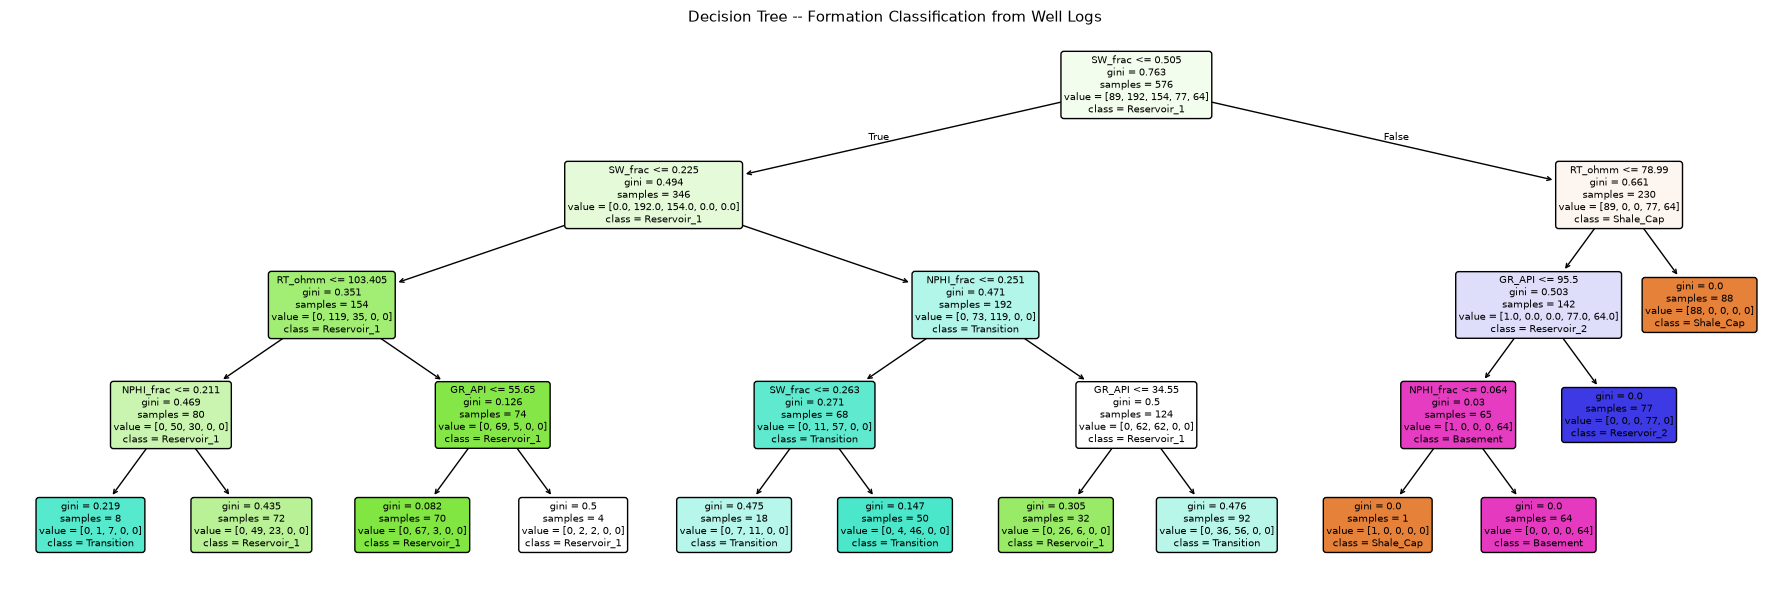

Read from top to bottom: each node shows the split condition, class counts, and predicted class.


In [8]:
# Visualise the decision tree -- see the rules the model learned
fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(
    model,
    feature_names=feature_cols,
    class_names=class_order,
    filled=True,
    rounded=True,
    fontsize=7,
    ax=ax
)
ax.set_title("Decision Tree -- Formation Classification from Well Logs", fontsize=11)
plt.tight_layout()
plt.show()
print("Read from top to bottom: each node shows the split condition, class counts, and predicted class.")

---
## 6. Evaluate the Model

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

| Metric | What it measures |
|--------|------------------|
| **Accuracy** | % of all predictions that were correct |
| **Precision** | Of all rows predicted as class X, how many actually were X? |
| **Recall** | Of all rows that actually are class X, how many did the model find? |
| **F1 Score** | Harmonic mean of precision and recall -- best single summary metric |
| **Confusion Matrix** | Table showing correct vs incorrect predictions for each class |

</div>

In [9]:
# Predictions and accuracy
y_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Training accuracy : {train_acc:.3f}  ({train_acc*100:.1f}%)")
print(f"Test accuracy     : {test_acc:.3f}  ({test_acc*100:.1f}%)")

gap = train_acc - test_acc
if gap > 0.10:
    print(f"\nWarning: {gap:.2f} gap between train and test accuracy -- possible overfitting.")
else:
    print(f"\nGap between train and test: {gap:.2f} -- model is generalising well.")

Training accuracy : 0.858  (85.8%)
Test accuracy     : 0.771  (77.1%)

Gap between train and test: 0.09 -- model is generalising well.


In [10]:
# Full classification report (precision, recall, F1 per class)
# Pass labels=class_order so the per-class rows line up with target_names.
# Without it, sklearn orders rows by SORTED label values and the custom
# names get attached to the wrong classes (same fix as the confusion matrix).
print(classification_report(y_test, y_pred, labels=class_order, target_names=class_order))

              precision    recall  f1-score   support

   Shale_Cap       1.00      1.00      1.00        19
 Reservoir_1       0.70      0.54      0.61        48
  Transition       1.00      1.00      1.00        16
 Reservoir_2       0.55      0.71      0.62        38
    Basement       1.00      1.00      1.00        23

    accuracy                           0.77       144
   macro avg       0.85      0.85      0.85       144
weighted avg       0.78      0.77      0.77       144



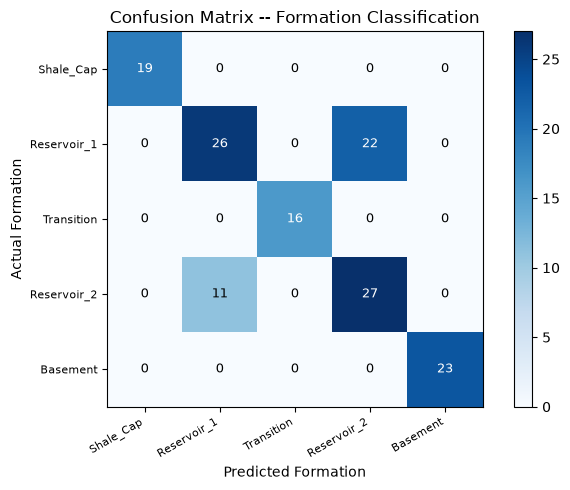

Diagonal = correct predictions. Off-diagonal = misclassified rows.


In [11]:
# Confusion matrix -- visualised as a heatmap
cm = confusion_matrix(y_test, y_pred, labels=class_order)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(list(range(len(class_order))))
ax.set_yticks(list(range(len(class_order))))
ax.set_xticklabels(class_order, rotation=30, ha="right", fontsize=8)
ax.set_yticklabels(class_order, fontsize=8)
ax.set_xlabel("Predicted Formation")
ax.set_ylabel("Actual Formation")
ax.set_title("Confusion Matrix -- Formation Classification")

for i in range(len(class_order)):
    for j in range(len(class_order)):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=9, color=color)

plt.tight_layout()
plt.show()
print("Diagonal = correct predictions. Off-diagonal = misclassified rows.")

### Reading the Confusion Matrix

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Each **row** is the actual formation. Each **column** is what the model predicted.

- **Diagonal cells** (top-left to bottom-right) are correct predictions -- you want these to be high.
- **Off-diagonal cells** are mistakes. If the model confuses Transition with Reservoir_1, that cell will be non-zero.
- Geologically, confusions between adjacent formations (e.g., Transition and Reservoir) are expected -- their log signatures overlap at the boundary.

</div>

---
## 7. Feature Importance

The Decision Tree ranks which logs contributed most to the classification decisions.
This tells you which measurements are most diagnostic for identifying formations.

Feature Importance (most to least diagnostic):
  SW_frac       0.4422  #################
  RT_ohmm       0.2667  ##########
  GR_API        0.2412  #########
  NPHI_frac     0.0500  #
  RHOB_gcc      0.0000  


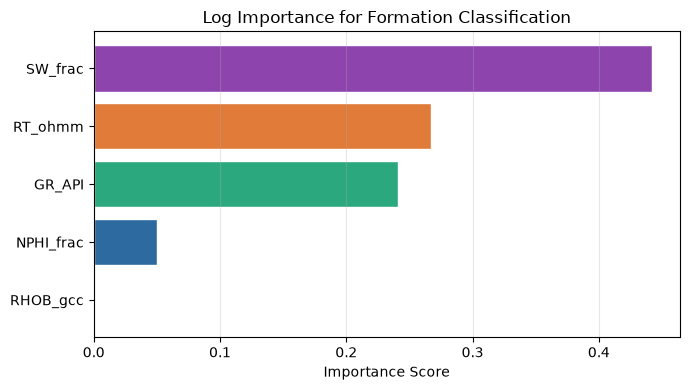

In [12]:
# Feature importance scores (sum to 1.0)
importances = model.feature_importances_
feat_names  = feature_cols

# Sort descending
sorted_idx    = list(np.argsort(importances)[::-1])
sorted_names  = [feat_names[i] for i in sorted_idx]
sorted_scores = [importances[i] for i in sorted_idx]

print("Feature Importance (most to least diagnostic):")
for name, score in zip(sorted_names, sorted_scores):
    bar = '#' * int(score * 40)
    print(f"  {name:12s}  {score:.4f}  {bar}")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#1a3a5c", "#2d6a9f", "#2ca87f", "#e07b39", "#8e44ad"]
ax.barh(sorted_names[::-1], sorted_scores[::-1], color=colors, edgecolor="white")
ax.set_xlabel("Importance Score")
ax.set_title("Log Importance for Formation Classification")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

---
## 8. Student Activity

<div style="background: #fff8e1; border-left: 5px solid #e07b39; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### 🎯 Tune the Tree

Retrain the model with `max_depth=2` and then with `max_depth=6`. For each:

1. Print train and test accuracy
2. Print the classification report
3. Record your findings in the markdown cell below

| max_depth | Train Accuracy | Test Accuracy | Best class | Worst class |
|-----------|---------------|---------------|------------|-------------|
| 2 | | | | |
| 4 (lesson model) | | | | |
| 6 | | | | |

**Questions:**
- Which depth gives the best test accuracy?
- At `max_depth=6`, is the training accuracy much higher than the test accuracy? What does that tell you?
- Which formation is hardest to classify? Can you explain why from what you know about well logs?

</div>

In [20]:
# 🎯 Your code here

# max_depth = 2
model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")
print(f"Tree depth (actual): {model.get_depth()}")
print(f"Number of leaves   : {model.get_n_leaves()}")

y_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Training accuracy : {train_acc:.3f}  ({train_acc*100:.1f}%)")
print(f"Test accuracy     : {test_acc:.3f}  ({test_acc*100:.1f}%)")

# max_depth = 6
model = DecisionTreeClassifier(max_depth=6, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")
print(f"Tree depth (actual): {model.get_depth()}")
print(f"Number of leaves   : {model.get_n_leaves()}")

y_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Training accuracy : {train_acc:.3f}  ({train_acc*100:.1f}%)")
print(f"Test accuracy     : {test_acc:.3f}  ({test_acc*100:.1f}%)")
print(classification_report(y_test, y_pred, labels=class_order, target_names=class_order))


Model trained!
Tree depth (actual): 2
Number of leaves   : 4
Training accuracy : 0.700  (70.0%)
Test accuracy     : 0.646  (64.6%)
Model trained!
Tree depth (actual): 6
Number of leaves   : 31
Training accuracy : 0.908  (90.8%)
Test accuracy     : 0.819  (81.9%)
              precision    recall  f1-score   support

   Shale_Cap       1.00      1.00      1.00        19
 Reservoir_1       0.78      0.65      0.70        48
  Transition       1.00      1.00      1.00        16
 Reservoir_2       0.63      0.76      0.69        38
    Basement       1.00      1.00      1.00        23

    accuracy                           0.82       144
   macro avg       0.88      0.88      0.88       144
weighted avg       0.83      0.82      0.82       144



*Write your answers here:*

- max_depth=2 findings: training accuracy is 10% greater than test acuracy
- max_depth=6 findings: training accuracy is 9.9% greater than the test accuracy
- Hardest formation to classify and why: nsition and reservoir, their log signatures overlap at the boundary


---
## 9. Recap & Homework

### 📝 What We Covered in Lesson 9

| Concept | Key Point |
|---------|----------|
| Classification | Predicts a label/category instead of a number |
| Decision Tree | Learns a sequence of if/else rules from data; human-readable |
| `max_depth` | Controls overfitting -- too deep memorises training data |
| `stratify=y` | Ensures class balance is preserved in the train/test split |
| Accuracy | Overall % correct -- can be misleading with imbalanced classes |
| Precision / Recall / F1 | Per-class metrics that give a fuller picture |
| Confusion matrix | Shows exactly which classes are confused with each other |
| Feature importance | Ranks which inputs the tree relied on most |

### 📝 Homework

<div style="background: #fff8e1; border-left: 5px solid #f39c12; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 10px 0;">

**Task 1 -- Binary Classification (All Students)**

Create a new target column: `Reservoir_Flag` = 1 if Formation is `Reservoir_1` or `Reservoir_2`, else 0.
Train a Decision Tree (`max_depth=3`) to classify each row as reservoir or non-reservoir.
Report accuracy, precision, recall, and F1 for the positive class (1 = reservoir).

</div>

<div style="background: #fff8e1; border-left: 5px solid #f39c12; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 10px 0;">

**Task 2 -- Per-Well Analysis (All Students)**

Train the 5-class formation model on Well_A, Well_B, and Well_C only.
Test it on Well_D (the held-out well). Report the test accuracy.
How does this compare to the random 80/20 split from the lesson? Why might they differ?

</div>

<div style="background: #fff8e1; border-left: 5px solid #f39c12; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 10px 0;">

**Task 3 -- Reduce Features (Engineering Track)**

Train the model using only the two most important features from Section 7.
Compare test accuracy and F1 with the full 5-feature model.
Plot a 2D scatter (x = most important feature, y = second most important)
with points coloured by Formation. Does the scatter show clear clusters?

</div>

Model trained!
Tree depth (actual): 2
Number of leaves   : 4


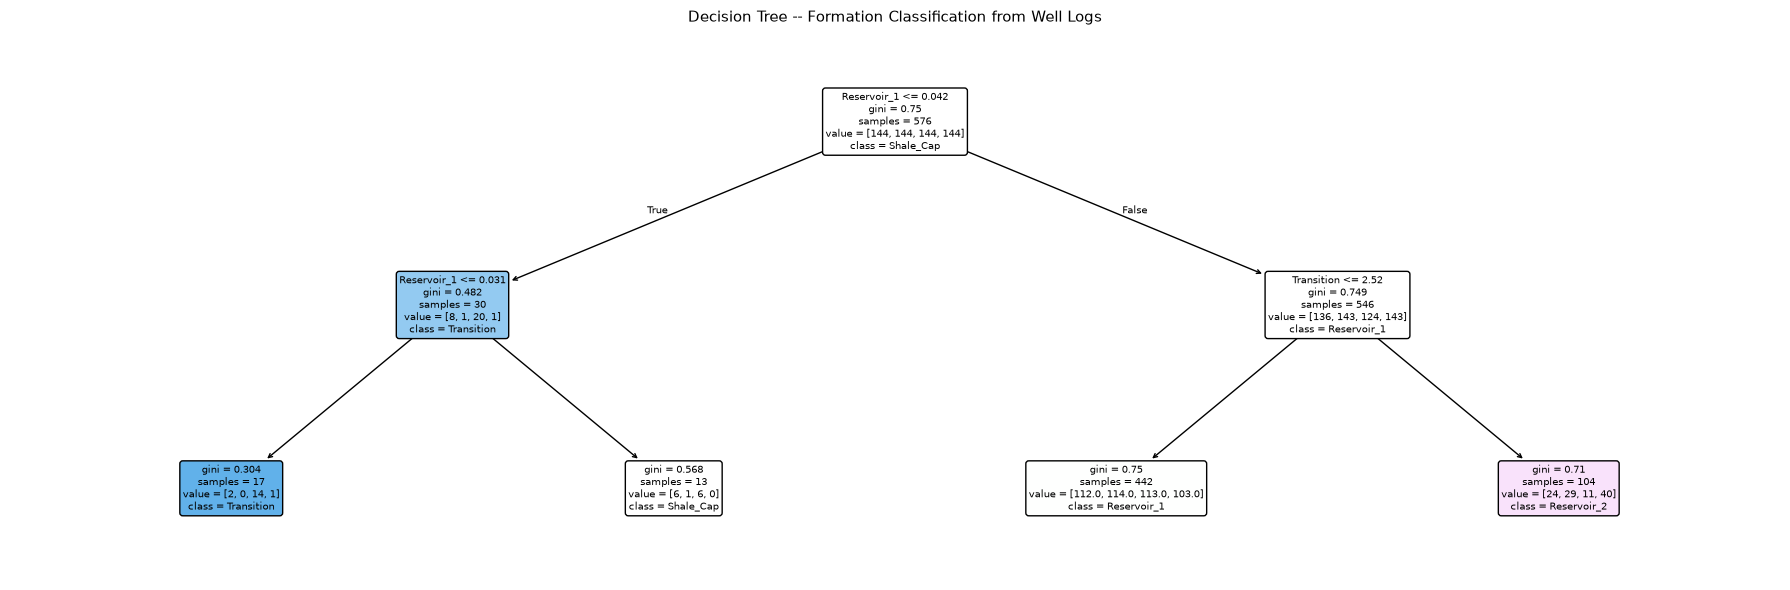

Read from top to bottom: each node shows the split condition, class counts, and predicted class.


In [52]:
# 📝 Task 1 -- Reservoir Flag binary classification
# Your code here
feature_cols = ["GR_API", "NPHI_frac", "RHOB_gcc", "RT_ohmm", "SW_frac"]
X = df[feature_cols]
y = df["Formation"]

class_order = ["Shale_Cap", "Reservoir_1", "Transition", "Reservoir_2", "Basement"]

def Reservoir_Flag(C):
    for C in class_order:
     if C == "Reservoir_1"or "Reservoir_2":
        return 1
    else: 
       return 0

df[Reservoir_Flag] = Reservoir_Flag(class_order)

model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")
print(f"Tree depth (actual): {model.get_depth()}")
print(f"Number of leaves   : {model.get_n_leaves()}")

fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(
    model,
    feature_names=class_order,
    class_names=class_order,
    filled=True,
    rounded=True,
    fontsize=7,
    ax=ax
)
ax.set_title("Decision Tree -- Formation Classification from Well Logs", fontsize=11)
plt.tight_layout()
plt.show()
print("Read from top to bottom: each node shows the split condition, class counts, and predicted class.")


In [53]:
# 📝 Task 2 -- Train on 3 wells, test on Well_D
# Your code here
feature_cols = ["GR_API", "NPHI_frac", "RHOB_gcc", "RT_ohmm", "SW_frac"]
X = df[feature_cols]
y = df["Well_ID"]

class_order = ["Well_A","Well_B","Well_C"]

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")
print(f"Tree depth (actual): {model.get_depth()}")
print(f"Number of leaves   : {model.get_n_leaves()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training rows : {len(X_train)}")
print(f"Test rows     : {len(X_test)}")
print("\nClass balance in training set:")
print(y_train.value_counts())
print("\nClass balance in testing set:")
print(y_test.value_counts())

y_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Training accuracy : {train_acc:.3f}  ({train_acc*100:.1f}%)")
print(f"Test accuracy     : {test_acc:.3f}  ({test_acc*100:.1f}%)")

gap = train_acc - test_acc
if gap > 0.10:
    print(f"\nWarning: {gap:.2f} gap between train and test accuracy -- possible overfitting.")
else:
    print(f"\nGap between train and test: {gap:.2f} -- model is generalising well.")

Model trained!
Tree depth (actual): 4
Number of leaves   : 14
Training rows : 576
Test rows     : 144

Class balance in training set:
Well_ID
Well_B    144
Well_C    144
Well_D    144
Well_A    144
Name: count, dtype: int64

Class balance in testing set:
Well_ID
Well_A    36
Well_C    36
Well_D    36
Well_B    36
Name: count, dtype: int64
Training accuracy : 0.396  (39.6%)
Test accuracy     : 0.292  (29.2%)



Feature Importance (most to least diagnostic):
  SW_frac       0.4422  #################
  RT_ohmm       0.2667  ##########
  GR_API        0.2412  #########
  NPHI_frac     0.0500  #
  RHOB_gcc      0.0000  
Model trained!
Tree depth (actual): 4
Number of leaves   : 12
Training rows : 576
Test rows     : 144

Class balance in training set:
Formation
Reservoir_1    192
Reservoir_2    154
Basement        89
Shale_Cap       77
Transition      64
Name: count, dtype: int64

Class balance in testing set:
Formation
Reservoir_1    48
Reservoir_2    38
Basement       23
Shale_Cap      19
Transition     16
Name: count, dtype: int64
Training accuracy : 0.858  (85.8%)
Test accuracy     : 0.771  (77.1%)

Gap between train and test: 0.09 -- model is generalising well.


KeyError: 'feature_cols'

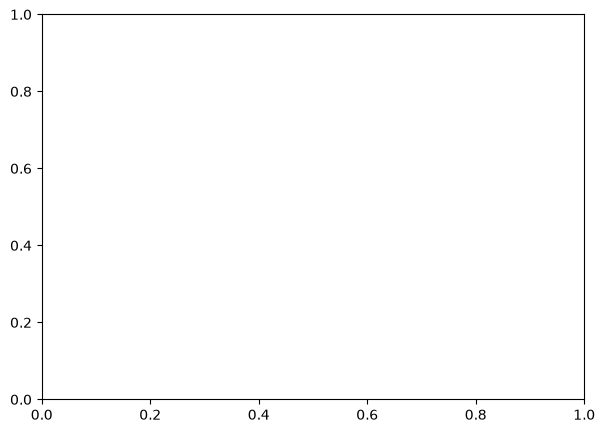

In [64]:
# 📝 Task 3 (Engineering) -- 2-feature model
# Your code here
importances = model.feature_importances_
feat_names  = feature_cols

# Sort descending
sorted_idx    = list(np.argsort(importances)[::-1])
sorted_names  = [feat_names[i] for i in sorted_idx]
sorted_scores = [importances[i] for i in sorted_idx]

print("Feature Importance (most to least diagnostic):")
for name, score in zip(sorted_names, sorted_scores):
    bar = '#' * int(score * 40)
    print(f"  {name:12s}  {score:.4f}  {bar}")

feature_cols = ["GR_API", "NPHI_frac", "RHOB_gcc", "RT_ohmm", "SW_frac"]
X = df[feature_cols]
y = df["Formation"]

class_order = [list("Formation")]

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")
print(f"Tree depth (actual): {model.get_depth()}")
print(f"Number of leaves   : {model.get_n_leaves()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training rows : {len(X_train)}")
print(f"Test rows     : {len(X_test)}")
print("\nClass balance in training set:")
print(y_train.value_counts())
print("\nClass balance in testing set:")
print(y_test.value_counts())

y_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Training accuracy : {train_acc:.3f}  ({train_acc*100:.1f}%)")
print(f"Test accuracy     : {test_acc:.3f}  ({test_acc*100:.1f}%)")

gap = train_acc - test_acc
if gap > 0.10:
    print(f"\nWarning: {gap:.2f} gap between train and test accuracy -- possible overfitting.")
else:
    print(f"\nGap between train and test: {gap:.2f} -- model is generalising well.")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_train["feature_cols"], y_train, alpha=0.2, s=10, color="#2d6a9f", label="Training data")
ax.scatter(X_test["feature_cols"], y_test, alpha=0.4, s=14, color="#2ca87f", label="Test data")
ax.plot(feature_cols, class_order, color="#c0392b", linewidth=2, label="Model prediction")
ax.set_xlabel("Feature")
ax.set_ylabel("Class")
ax.set_title("Linear Regression -- NPHI Predicted from RHOB")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2d6a9f 100%); padding: 24px 28px; border-radius: 10px; margin-top: 16px; text-align: center;">
  <h3 style="color: #ffffff; margin: 0 0 10px 0;">Lesson 9 Complete!</h3>
  <p style="color: #a8d4f5; margin: 0 0 10px 0;">
    You have now built both a regression model and a classification model -- the two
    pillars of supervised machine learning. You can train, visualise, and evaluate
    a Decision Tree on real petrophysical data.
  </p>
  <p style="color: #d0eaff; font-size: 0.9em; margin: 0;">
    Next: <strong>Lesson 10 -- Model Improvement: Cross-Validation &amp; Random Forests</strong>
  </p>
</div>